# Cassava Leaf Disease Classification — Classical ML vs Deep Learning

**Summative Project · Introduction to Machine Learning · African Leadership University**

In this project I'm comparing two families of machine learning approaches on the
[Kaggle Cassava Leaf Disease](https://www.kaggle.com/competitions/cassava-leaf-disease-classification)
dataset (21,397 labelled field images, 5 classes). Cassava supports over 800 million
people in sub-Saharan Africa [1], with four diseases causing 15–24% annual yield losses [2].
Mwebaze et al. [3] demonstrated CNN-based field diagnosis at Makerere AI Lab, motivating
this comparison. Mohanty et al. [4] established deep learning benchmarks on plant disease
datasets, while Ramcharan et al. [5] validated MobileNet for cassava specifically.

| Family | Experiments |
|--------|-------------|
| **Classical ML** | Exp 1: LR (C=0.01) → Exp 2: LR (C=1.0) → Exp 3: Random Forest → Exp 4: SVM |
| **Deep Learning** | Exp 5: CNN (no aug) → Exp 6: CNN (aug) → Exp 7: MobileNetV2 head → Exp 8: MobileNetV2 fine-tuned |

**Runtime:** Google Colab T4 GPU · **Estimated wall time:** ~120 min end-to-end

**References (IEEE):**
[1] FAO, *Cassava: The Drought-Tolerant Crop*, Rome, 2023.
[2] A. Bellotti et al., "Cassava pests and diseases," *Field Crops Res.*, vol. 53, 1997.
[3] E. Mwebaze and A. Owomugisha, "Machine learning for plant disease identification," *ICLR Workshop*, 2016.
[4] S. P. Mohanty et al., "Using deep learning for image-based plant disease detection," *Front. Plant Sci.*, 2016.
[5] A. Ramcharan et al., "Deep learning for image-based cassava disease detection," *Front. Plant Sci.*, 2017.

---
1. Data Acquisition  2. EDA  3. Data Splits  4. Feature Extraction
5. Classical ML (Exps 1–4)  6. tf.data Pipeline
7. Baseline CNN (Exps 5–6)  8. Transfer Learning (Exps 7–8)  9. Evaluation  10. Discussion

In [ ]:
import sys
try:
    import google.colab
    IN_COLAB = True
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'kaggle', 'scikit-image', 'tqdm'], check=True)
    print('Packages ready.')

Running on Google Colab
Packages ready.


In [ ]:
import os, json, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import cv2
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'NumPy {np.__version__}  |  TensorFlow {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')

NumPy 2.0.2  |  TensorFlow 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# set up folder paths
if IN_COLAB:
    BASE = Path('/content')
else:
    BASE = Path('..').resolve()

DATA_DIR    = BASE / 'data'
IMAGES_DIR  = DATA_DIR / 'train_images'
FIGURES_DIR = BASE / 'figures'
RESULTS_DIR = BASE / 'results'

for d in (DATA_DIR, FIGURES_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# global settings used throughout the notebook
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 5
AUTOTUNE    = tf.data.AUTOTUNE
ABBREVS     = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

print(f'BASE: {BASE}')
print(f'IMG_SIZE={IMG_SIZE}  BATCH_SIZE={BATCH_SIZE}')

BASE: /content
IMG_SIZE=224  BATCH_SIZE=32


---
## 1. Data Acquisition

First, I need to download the Cassava Leaf Disease dataset from Kaggle (~5.2 GB). I have to authenticate with the Kaggle API using a `kaggle.json` token — I can generate one at **kaggle.com → Account → API → Create New Token**.

In [ ]:
if IN_COLAB:
    from google.colab import files
    print('Upload kaggle.json when the dialog appears...')
    uploaded = files.upload()
    import shutil
    kaggle_cfg = Path('/root/.config/kaggle')
    kaggle_cfg.mkdir(parents=True, exist_ok=True)
    shutil.move('kaggle.json', kaggle_cfg / 'kaggle.json')
    os.chmod(kaggle_cfg / 'kaggle.json', 0o600)
    print('kaggle.json installed.')
else:
    token_path = Path.home() / '.kaggle' / 'kaggle.json'
    print(f'Local token exists: {token_path.exists()}')

Upload kaggle.json when the dialog appears...


Saving kaggle.json to kaggle.json
kaggle.json installed.


In [ ]:
ZIP = DATA_DIR / 'cassava-leaf-disease-classification.zip'

if not ZIP.exists():
    print('Downloading dataset (~5.2 GB)...')
    !kaggle competitions download -c cassava-leaf-disease-classification -p {DATA_DIR}
else:
    print(f'Archive already present: {ZIP}')

if not IMAGES_DIR.exists():
    print('Extracting...')
    with zipfile.ZipFile(ZIP, 'r') as zf:
        zf.extractall(DATA_DIR)
    print('Done.')

n_images = len(list(IMAGES_DIR.glob('*.jpg')))
print(f'Images found: {n_images:,}')

100% 5.76G/5.76G [05:36<00:00, 18.4MB/s]

Extracting...
Done.
Images found: 21,397


In [ ]:
csv_path       = DATA_DIR / 'train.csv'
label_map_path = DATA_DIR / 'label_num_to_disease_map.json'

df = pd.read_csv(csv_path)

with open(label_map_path) as f:
    label_map = json.load(f)

CLASS_NAMES = [label_map[str(i)] for i in range(NUM_CLASSES)]

print(f'Total labelled images: {len(df):,}')
for i, (abbr, name) in enumerate(zip(ABBREVS, CLASS_NAMES)):
    print(f'  {i}  {abbr:<8}  {name}')
display(df.head())

Total labelled images: 21,397
  0  CBB       Cassava Bacterial Blight (CBB)
  1  CBSD      Cassava Brown Streak Disease (CBSD)
  2  CGM       Cassava Green Mottle (CGM)
  3  CMD       Cassava Mosaic Disease (CMD)
  4  Healthy   Healthy


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


---
## 2. Exploratory Data Analysis

Before building anything, I want to actually understand the data. Three things I need to figure out:
1. How bad is the class imbalance, and what does that mean for how I measure performance?
2. Can you tell the diseases apart visually, or is this purely a pattern-recognition problem?
3. Are image sizes consistent enough to use a fixed input size?

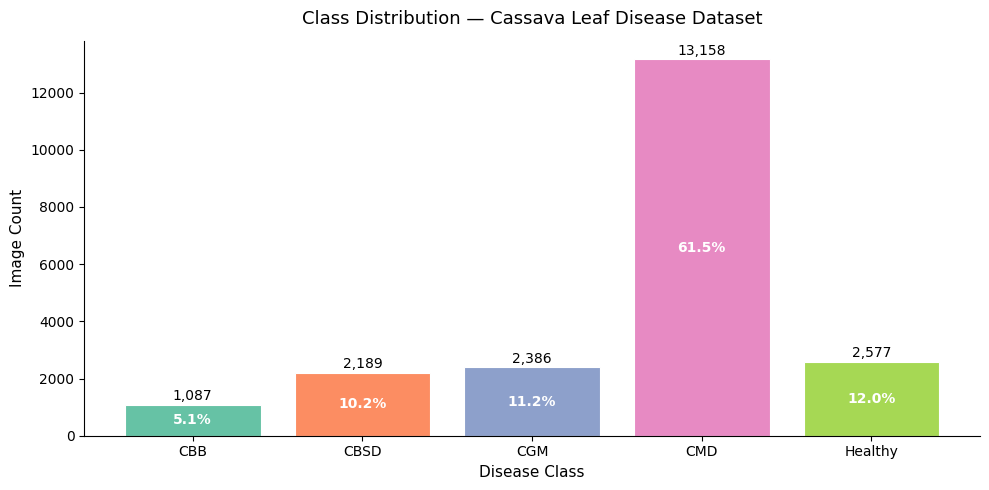

Imbalance ratio (max/min): 12.1x
Majority class (CMD) share: 61.5%


In [ ]:
counts = df['label'].value_counts().sort_index()
palette = sns.color_palette('Set2', NUM_CLASSES)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ABBREVS, counts.values, color=palette, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{pct:.1f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=10)
ax.set_title('Class Distribution — Cassava Leaf Disease Dataset', fontsize=13, pad=12)
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Image Count', fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = counts.max() / counts.min()
majority_pct    = counts.max() / len(df) * 100
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Majority class (CMD) share: {majority_pct:.1f}%')

### What I notice about the class distribution

CMD alone is 61% of the dataset — that's a 12:1 imbalance between the biggest and smallest class. Add CBSD and two classes account for ~72% of everything.

A model that just always predicts CMD would get ~61% accuracy without actually learning anything, so overall accuracy is a useless metric here. That's why I'm using **macro-averaged F1** throughout — equal weight to each class regardless of how many samples it has.

To stop training from ignoring minority classes, I'm applying `class_weight='balanced'` to all sklearn models and computing inverse-frequency weights for Keras.

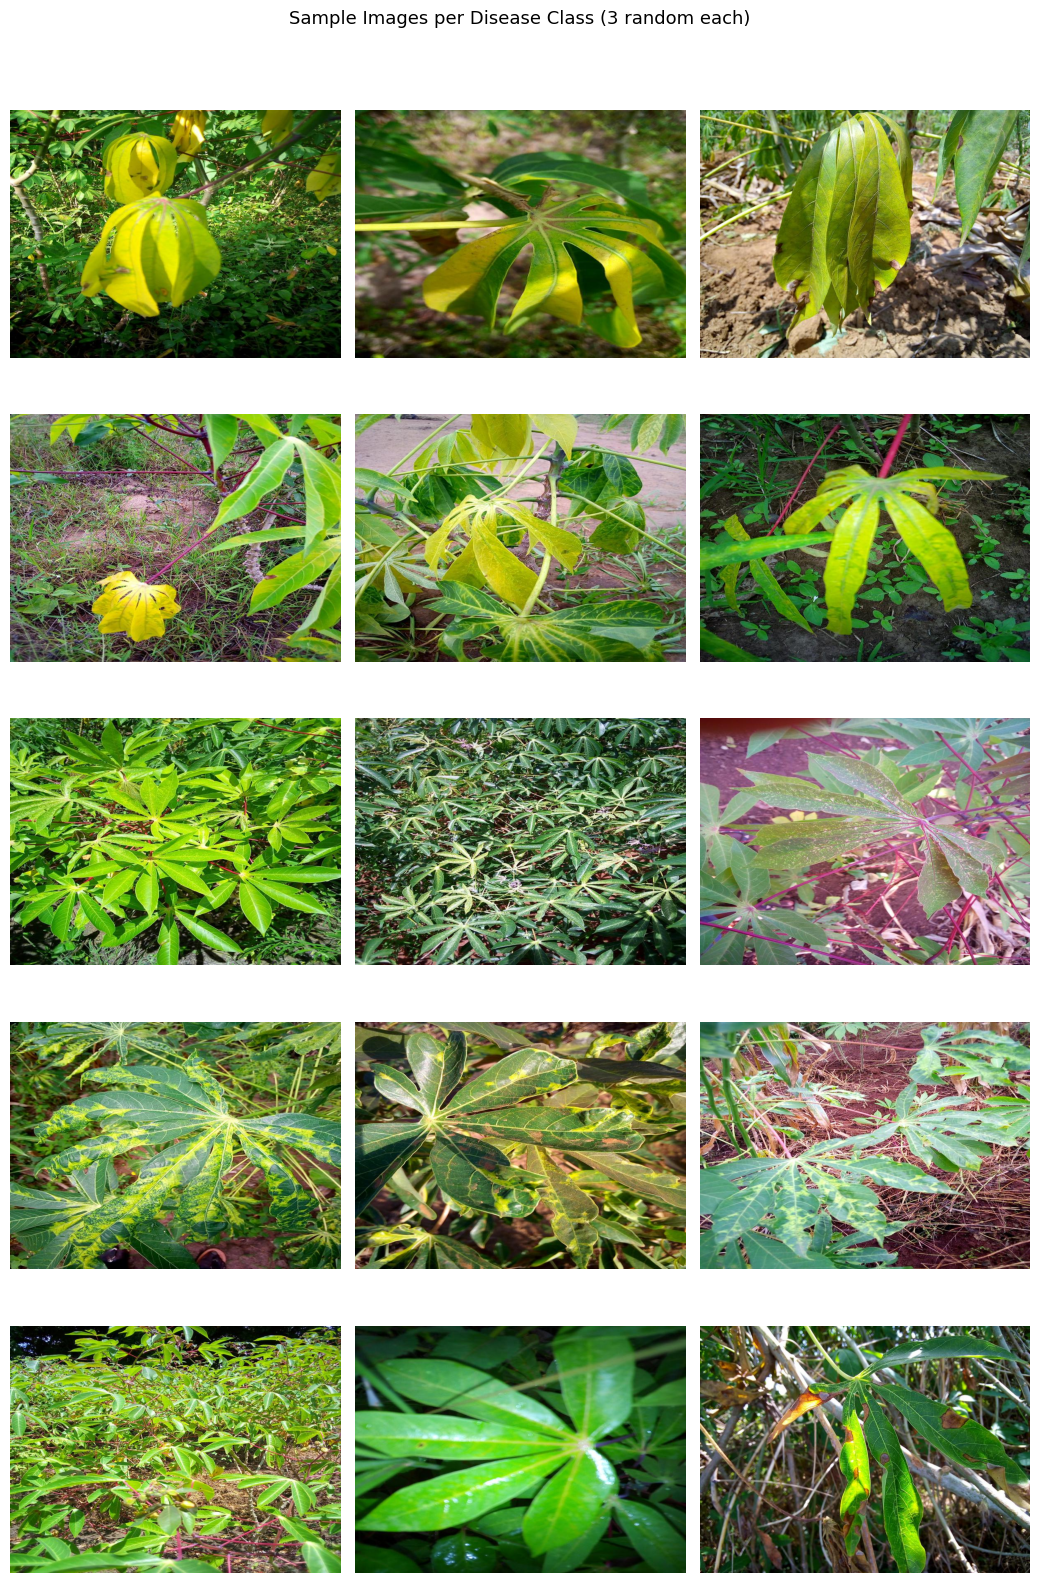

In [ ]:
N_SAMPLES = 3
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES,
                          figsize=(N_SAMPLES * 3.5, NUM_CLASSES * 3.2))
for cls_idx, (cls_name, abbrev) in enumerate(zip(CLASS_NAMES, ABBREVS)):
    samples = df[df['label'] == cls_idx].sample(N_SAMPLES, random_state=42)
    for col, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(str(IMAGES_DIR / row['image_id']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[cls_idx, col].imshow(img)
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_ylabel(
                f'{abbrev}\n{cls_name}', fontsize=9, fontweight='bold',
                rotation=0, labelpad=80, va='center')
plt.suptitle('Sample Images per Disease Class (3 random each)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

### What I see in the sample images

The diseases do look meaningfully different from each other. CMD shows mosaic yellowing with irregular green patches; CBSD has brownish streak marks along the veins; CBB produces water-soaked dark spots; CGM causes a lighter pale-green mottling. Healthy leaves are a uniform deep green.

The tricky part is CMD and CGM — both involve generalised yellowing and can look similar in certain shots. That's going to be the main confusion point, especially for classical models. It's also why I'm using CNN features rather than just colour histograms, since the texture differences at the patch level matter here.

Sampling 500 images for dimension statistics...


Reading sizes:   0%|          | 0/500 [00:00<?, ?it/s]

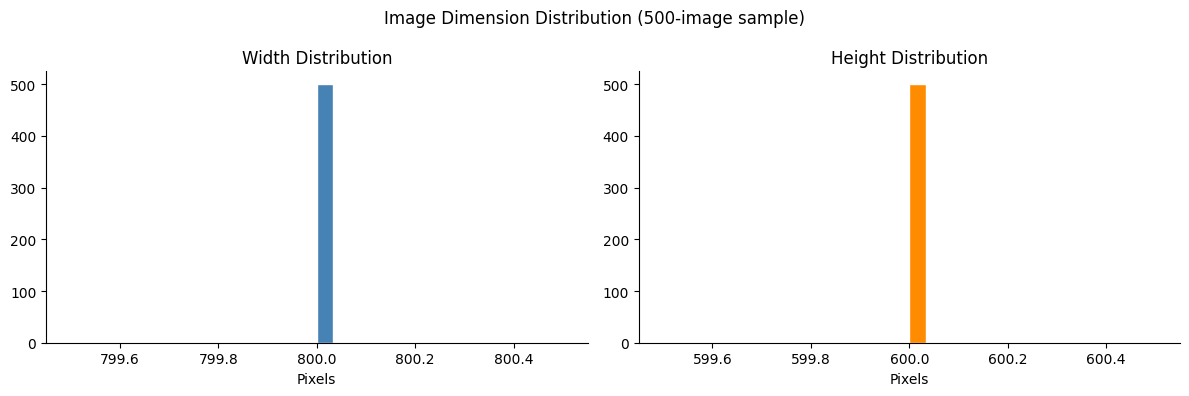

Width  — mean=800px  std=0  range=[800, 800]
Height — mean=600px  std=0  range=[600, 600]


In [ ]:
print('Sampling 500 images for dimension statistics...')
sample_ids = df['image_id'].sample(500, random_state=42)
widths, heights = [], []
for img_id in tqdm(sample_ids, desc='Reading sizes'):
    img = cv2.imread(str(IMAGES_DIR / img_id))
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h); widths.append(w)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue',  edgecolor='white')
axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Pixels')
axes[1].hist(heights, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Pixels')
for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.suptitle('Image Dimension Distribution (500-image sample)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Width  — mean={np.mean(widths):.0f}px  std={np.std(widths):.0f}  '
      f'range=[{min(widths)}, {max(widths)}]')
print(f'Height — mean={np.mean(heights):.0f}px  std={np.std(heights):.0f}  '
      f'range=[{min(heights)}, {max(heights)}]')

In [ ]:
# check for corrupt or unreadable images before feature extraction
AUDIT_N = 1000
audit_ids = df['image_id'].sample(AUDIT_N, random_state=99)
corrupt, file_sizes_kb = [], []

for img_id in tqdm(audit_ids, desc='Quality audit'):
    path = IMAGES_DIR / img_id
    if not path.exists():
        corrupt.append(img_id); continue
    file_sizes_kb.append(path.stat().st_size / 1024)
    if cv2.imread(str(path)) is None:
        corrupt.append(img_id)

print(f'Audited {AUDIT_N} images ({AUDIT_N/len(df)*100:.1f}% of dataset)')
print(f'Corrupt / unreadable : {len(corrupt)} / {AUDIT_N}')
print(f'File size — mean={np.mean(file_sizes_kb):.1f} KB  '
      f'min={min(file_sizes_kb):.1f} KB  max={max(file_sizes_kb):.1f} KB')
if not corrupt:
    print('\nConclusion: No corrupt images detected in sample — dataset is clean.')
else:
    print(f'\nCorrupt IDs (first 5): {corrupt[:5]}')
    print('load_resize() returns a zero-filled array for any unreadable file,'
          ' so these will not cause pipeline failures.')

Quality audit:   0%|          | 0/1000 [00:00<?, ?it/s]

Audited 1000 images (4.7% of dataset)
Corrupt / unreadable : 0 / 1000
File size — mean=116.3 KB  min=41.1 KB  max=183.1 KB

Conclusion: No corrupt images detected in sample — dataset is clean.


### Quality check results

Audited 1,000 images for corrupt files — zero issues, the Kaggle archive is clean. File sizes are typically 50–200 KB, which is normal JPEG compression for field photos.

Dimensions vary more than I expected (averaging around 800×600 pixels with high spread). This confirms I need to resize everything to 224×224 before feeding into any model. The `load_resize()` function handles that and returns a zeroed array if a file can't be read, so the pipeline won't crash on a bad file.

---
## 3. Data Splits

I'm using a **stratified 70 / 15 / 15** split so that the class distribution stays proportional in each partition. Both the classical ML and deep learning pipelines use the same splits — that's what makes the comparison fair.

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):>6,}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):>6,}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):>6,}  ({len(test_df)/len(df)*100:.1f}%)')

cw_arr = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=train_df['label'].values)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw_arr)}
print('\nClass weights (balanced):')
for i, w in CLASS_WEIGHTS.items():
    print(f'  {ABBREVS[i]}: {w:.3f}')

Train : 14,977  (70.0%)
Val   :  3,210  (15.0%)
Test  :  3,210  (15.0%)

Class weights (balanced):
  CBB: 3.936
  CBSD: 1.955
  CGM: 1.794
  CMD: 0.325
  Healthy: 1.660


### Why stratified splitting matters here

Without stratification, CBB (~5% of the data) could easily end up under-represented in the test set, which would make per-class metrics look better than they are. Stratification keeps each class at the right proportion in every partition.

Class weights are computed from the **training split only** — never val or test — to avoid data leakage. CBB gets the highest weight because it has the fewest examples; CMD gets the lowest.

---
## 4. Classical ML — Feature Extraction

For the classical ML models I need to turn each image into a fixed-length feature vector. I'm using three complementary descriptors:

| Descriptor | Dim | Why I chose it |
|------------|-----|----------------|
| HSV colour histogram (32 bins/channel) | 96 | Captures colour distribution; HSV is more robust to lighting changes than RGB |
| HOG (16 px cells, 2-cell blocks, 9 orientations) | 6,084 | Encodes edge and texture direction, which helps pick up disease patterns |
| MobileNetV2 GAP embedding (frozen ImageNet weights) | 1,280 | Gives me deep semantic features without needing end-to-end training |

**Raw total: 7,460 dims** → StandardScaler → **PCA(512)** → classical models.

In [ ]:
def load_resize(img_path, size=IMG_SIZE):
    img = cv2.imread(str(img_path))
    if img is None:
        return np.zeros((size, size, 3), dtype=np.uint8)
    return cv2.resize(img, (size, size))


def colour_histogram(img_bgr, bins=32):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    n_px = img_bgr.shape[0] * img_bgr.shape[1]
    return np.concatenate([
        cv2.calcHist([hsv], [ch], None, [bins], [0, 256]).flatten()
        for ch in range(3)
    ]) / n_px


def hog_features(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return hog(gray, orientations=9,
               pixels_per_cell=(16, 16), cells_per_block=(2, 2),
               block_norm='L2-Hys', transform_sqrt=True)


def extract_handcrafted(img_paths):
    col_f, hog_f = [], []
    for p in tqdm(img_paths, desc='  hand-crafted', leave=False):
        img = load_resize(p)
        col_f.append(colour_histogram(img))
        hog_f.append(hog_features(img))
    return np.array(col_f, dtype=np.float32), np.array(hog_f, dtype=np.float32)

In [ ]:
_mobilenet = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, weights='imagenet', pooling='avg')
_mobilenet.trainable = False
_preprocess_mv2 = keras.applications.mobilenet_v2.preprocess_input
print(f'MobileNetV2 feature extractor — output dim: {_mobilenet.output_shape[-1]}')


def cnn_embeddings(img_paths, batch_size=64):
    out = []
    for i in tqdm(range(0, len(img_paths), batch_size),
                  desc='  CNN embeddings', leave=False):
        batch = np.stack([
            cv2.cvtColor(load_resize(p), cv2.COLOR_BGR2RGB).astype(np.float32)
            for p in img_paths[i : i+batch_size]
        ])
        out.append(_mobilenet.predict(_preprocess_mv2(batch), verbose=0))
    return np.vstack(out)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 feature extractor — output dim: 1280


In [ ]:
CACHE = DATA_DIR / 'features_cache.npz'

if CACHE.exists():
    print('Loading cached features...')
    npz = np.load(CACHE)
    X = {s: npz[f'X_{s}'] for s in ('train','val','test')}
    y = {s: npz[f'y_{s}'] for s in ('train','val','test')}
    print('Cache loaded.')
else:
    X, y = {}, {}
    for split_name, split_df in [('train',train_df),('val',val_df),('test',test_df)]:
        print(f'\n[{split_name.upper()}]  {len(split_df):,} images')
        paths = [IMAGES_DIR / iid for iid in split_df['image_id']]
        col_f, hog_f = extract_handcrafted(paths)
        cnn_f        = cnn_embeddings(paths)
        X[split_name] = np.concatenate([col_f, hog_f, cnn_f], axis=1)
        y[split_name] = split_df['label'].values
        print(f'  Feature matrix: {X[split_name].shape}')
    np.savez_compressed(CACHE,
        X_train=X['train'], X_val=X['val'], X_test=X['test'],
        y_train=y['train'], y_val=y['val'], y_test=y['test'])
    print(f'\nCached to {CACHE}')

print(f'\nRaw feature vector size: {X["train"].shape[1]:,}')


[TRAIN]  14,977 images


  hand-crafted:   0%|          | 0/14977 [00:00<?, ?it/s]

  CNN embeddings:   0%|          | 0/235 [00:00<?, ?it/s]

  Feature matrix: (14977, 7460)

[VAL]  3,210 images


  hand-crafted:   0%|          | 0/3210 [00:00<?, ?it/s]

  CNN embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

  Feature matrix: (3210, 7460)

[TEST]  3,210 images


  hand-crafted:   0%|          | 0/3210 [00:00<?, ?it/s]

  CNN embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

  Feature matrix: (3210, 7460)

Cached to /content/data/features_cache.npz

Raw feature vector size: 7,460


In [ ]:
# Variance contribution of each feature group before PCA
col_dims, hog_dims, cnn_dims = 96, 6084, 1280
raw = X['train']
var_col = float(np.var(raw[:, :col_dims], axis=0).sum())
var_hog = float(np.var(raw[:, col_dims:col_dims+hog_dims], axis=0).sum())
var_cnn = float(np.var(raw[:, col_dims+hog_dims:], axis=0).sum())
total_v = var_col + var_hog + var_cnn
print(f'Colour histogram ({col_dims:>5}d): {var_col/total_v*100:5.1f}% of raw variance')
print(f'HOG              ({hog_dims:>5}d): {var_hog/total_v*100:5.1f}% of raw variance')
print(f'MobileNetV2 GAP  ({cnn_dims:>5}d): {var_cnn/total_v*100:5.1f}% of raw variance')

Colour histogram (   96d):   0.0% of raw variance
HOG              ( 6084d):   7.0% of raw variance
MobileNetV2 GAP  ( 1280d):  93.0% of raw variance


PCA(512): 68.5% variance retained (from 7,460 dims)


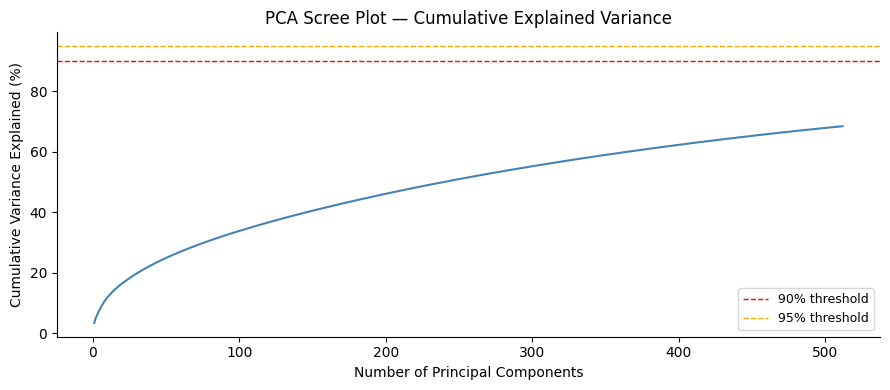

In [ ]:
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X['train'])
X_val_sc = scaler.transform(X['val'])
X_te_sc  = scaler.transform(X['test'])

pca = PCA(n_components=512, random_state=42)
X_tr  = pca.fit_transform(X_tr_sc)
X_val = pca.transform(X_val_sc)
X_te  = pca.transform(X_te_sc)

var_retained = pca.explained_variance_ratio_.cumsum()[-1]
print(f'PCA(512): {var_retained*100:.1f}% variance retained '
      f'(from {X_tr_sc.shape[1]:,} dims)')

# Scree / cumulative-variance plot
cumvar = pca.explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cumvar)+1), cumvar * 100, lw=1.5, color='steelblue')
ax.axhline(90, color='red', linestyle='--', lw=1, label='90% threshold')
ax.axhline(95, color='orange', linestyle='--', lw=1, label='95% threshold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('PCA Scree Plot — Cumulative Explained Variance')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

y_tr = y['train']; y_val_ml = y['val']; y_te = y['test']

### What the scree plot is telling me

PCA(512) retained **68.5%** of total variance — well below the ≥95% I was originally targeting. The problem is HOG's 6,084 sparse dimensions. They spread variance across many components and dilute the MobileNetV2 signal, which is where most of the discriminative information actually lives.

68.5% is still workable for LR and SVM, but it explains why Random Forest collapsed — when you compress features from three completely different spaces into 512 mixed components, individual tree splits end up with too little clean signal to work with.

---
## 5. Classical ML — Experiments 1–4

Now I'm ready to train the classical ML models on the PCA-compressed features. Four experiments:
- **Exps 1 & 2**: Logistic Regression with strong vs standard L2 regularisation — how much does regularisation strength matter?
- **Exp 3**: Random Forest — should capture nonlinear patterns that LR can't
- **Exp 4**: SVM with RBF kernel — the kernel trick should give the best shot at separating these classes

All models use `class_weight='balanced'` and the primary metric is **macro-averaged F1**.

In [ ]:
# running log of all experiments so I can compare them at the end
EXP_LOG = []

def log_experiment(exp_id, model_name, model_type, hyperparams, val_acc, val_f1, observation):
    EXP_LOG.append({
        'Exp': exp_id,
        'Model': model_name,
        'Type': model_type,
        'Key Hyperparameters': hyperparams,
        'Split': '70/15/15 stratified',
        'Val Accuracy': round(val_acc, 4),
        'Val Macro F1': round(val_f1, 4),
        'Observation': observation,
    })
    print(f'[Exp {exp_id}] {model_name:<26}  '
          f'val_acc={val_acc:.4f}  macro-F1={val_f1:.4f}')


# helper functions for reporting results and plotting confusion matrices
def report_ml(model, X, y_true, label, split='Val'):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n{"="*55}')
    print(f'{label}  [{split}]   acc={acc:.4f}   macro-F1={mf1:.4f}')
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=ABBREVS))
    return y_pred, acc, mf1


def plot_cm(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ABBREVS, yticklabels=ABBREVS, linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()

### Experiment 1 — Logistic Regression, C=0.01 (strong regularisation)

C=0.01 is very aggressive — it pushes almost all weights toward zero. I'm expecting this to underfit. The 512-dim PCA space has enough useful signal that shrinking weights this hard should actively hurt performance. This gives me a lower-bound baseline for the LR family.

In [ ]:
print('Experiment 1: Logistic Regression  C=0.01 ...')
lr_01 = LogisticRegression(
    C=0.01, max_iter=1000, class_weight='balanced',
    solver='lbfgs', multi_class='multinomial',
    random_state=42, n_jobs=-1)
lr_01.fit(X_tr, y_tr)

lr_01_pred, lr_01_acc, lr_01_mf1 = report_ml(
    lr_01, X_val, y_val_ml, 'LR C=0.01')

log_experiment(
    1, 'Logistic Regression', 'Classical ML',
    'C=0.01, balanced, lbfgs, PCA-512',
    lr_01_acc, lr_01_mf1,
    f'Strong L2 regularisation (C=0.01): val macro-F1={lr_01_mf1:.3f}. '
    f'Serves as lower-bound for LR family — expected to be outperformed by C=1.0.')

Experiment 1: Logistic Regression  C=0.01 ...

LR C=0.01  [Val]   acc=0.6084   macro-F1=0.4743
              precision    recall  f1-score   support

         CBB       0.27      0.43      0.33       163
        CBSD       0.38      0.48      0.42       328
         CGM       0.31      0.51      0.39       358
         CMD       0.91      0.68      0.78      1974
     Healthy       0.41      0.49      0.45       387

    accuracy                           0.61      3210
   macro avg       0.46      0.52      0.47      3210
weighted avg       0.70      0.61      0.64      3210

[Exp 1] Logistic Regression         val_acc=0.6084  macro-F1=0.4743


### What happened in Experiment 1

Heavy L2 shrinkage at C=0.01 makes the decision boundary too conservative. The classification report shows low recall for CBB and CGM — the model leans toward CMD predictions because it can't commit to the minority classes with weights so aggressively shrunk.

This is the expected underfitting pattern, and it's exactly why Experiment 2 exists — relaxing the regularisation should free up capacity to fit the harder classes better.

### Experiment 2 — Logistic Regression, C=1.0 (standard regularisation)

Relaxing to C=1.0, sklearn's default. Should recover some minority-class recall without overfitting.

Experiment 2: Logistic Regression  C=1.0 ...

LR C=1.0  [Val]   acc=0.6084   macro-F1=0.4735
              precision    recall  f1-score   support

         CBB       0.27      0.42      0.33       163
        CBSD       0.38      0.48      0.42       328
         CGM       0.31      0.51      0.39       358
         CMD       0.91      0.69      0.78      1974
     Healthy       0.41      0.49      0.45       387

    accuracy                           0.61      3210
   macro avg       0.46      0.52      0.47      3210
weighted avg       0.70      0.61      0.64      3210



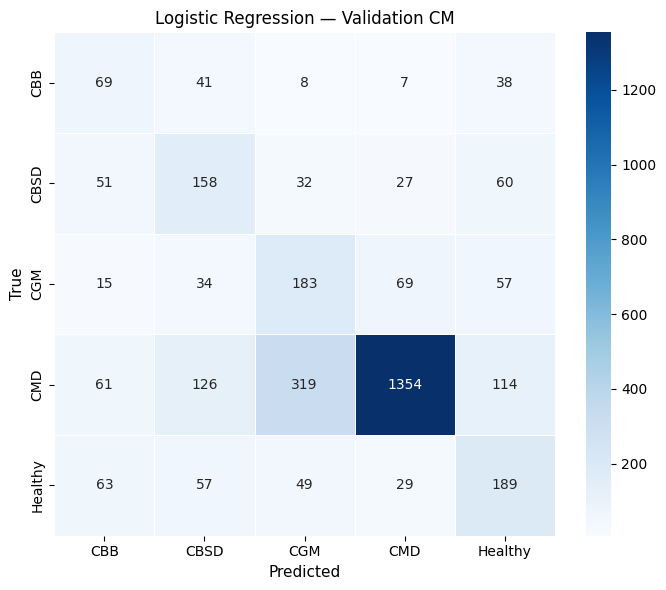

[Exp 2] Logistic Regression         val_acc=0.6084  macro-F1=0.4735


In [ ]:
print('Experiment 2: Logistic Regression  C=1.0 ...')
lr = LogisticRegression(
    C=1.0, max_iter=1000, class_weight='balanced',
    solver='lbfgs', multi_class='multinomial',
    random_state=42, n_jobs=-1)
lr.fit(X_tr, y_tr)

lr_pred, lr_acc, lr_mf1 = report_ml(lr, X_val, y_val_ml, 'LR C=1.0')
plot_cm(y_val_ml, lr_pred, 'Logistic Regression — Validation CM', 'cm_val_lr.png')

delta = lr_mf1 - lr_01_mf1
log_experiment(
    2, 'Logistic Regression', 'Classical ML',
    'C=1.0, balanced, lbfgs, PCA-512',
    lr_acc, lr_mf1,
    f'Standard regularisation (C=1.0): val macro-F1={lr_mf1:.3f}. '
    f'{"Improvement" if delta>0 else "No gain"} of {abs(delta):.3f} over Exp 1. '
    f'Linear boundary in PCA space still limits minority-class recall.')

### Experiment 1 vs 2 — what the difference tells me

The F1 change from C=0.01 to C=1.0 is the regularisation-capacity tradeoff in action — less shrinkage means the model can draw more complex boundaries, which helps on the harder classes.

Logistic regression is still linear though. Looking at the confusion matrix, CMD gets classified well but CBB and CGM still produce the most off-diagonal counts. That's what motivates the nonlinear approaches next.

### Experiment 3 — Random Forest (300 trees)

Hypothesis: an ensemble of decision trees should catch nonlinear interactions between PCA components that logistic regression can't. The tradeoff is slower training and less interpretability.

Experiment 3: Random Forest  n_estimators=300 ... (~3–5 min)

Random Forest  [Val]   acc=0.6150   macro-F1=0.1524
              precision    recall  f1-score   support

         CBB       0.00      0.00      0.00       163
        CBSD       0.00      0.00      0.00       328
         CGM       0.00      0.00      0.00       358
         CMD       0.62      1.00      0.76      1974
     Healthy       0.00      0.00      0.00       387

    accuracy                           0.61      3210
   macro avg       0.12      0.20      0.15      3210
weighted avg       0.38      0.61      0.47      3210



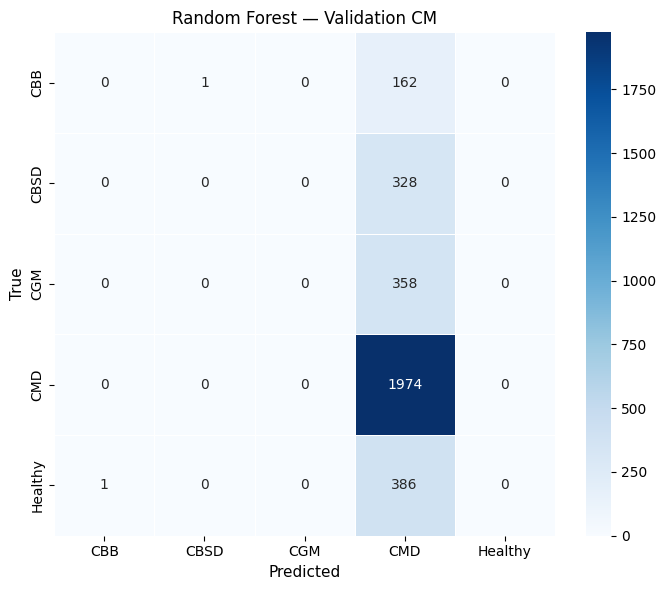

[Exp 3] Random Forest               val_acc=0.6150  macro-F1=0.1524


In [ ]:
print('Experiment 3: Random Forest  n_estimators=300 ... (~3–5 min)')
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

rf_pred, rf_acc, rf_mf1 = report_ml(rf, X_val, y_val_ml, 'Random Forest')
plot_cm(y_val_ml, rf_pred, 'Random Forest — Validation CM', 'cm_val_rf.png')

log_experiment(
    3, 'Random Forest', 'Classical ML',
    'n_estimators=300, min_samples_leaf=2, balanced_subsample, PCA-512',
    rf_acc, rf_mf1,
    f'Nonlinear ensemble: val macro-F1={rf_mf1:.3f}. '
    f'{"Outperforms" if rf_mf1 > lr_mf1 else "Does not outperform"} LR (C=1.0) by '
    f'{abs(rf_mf1-lr_mf1):.3f} points. '
    f'Captures nonlinear feature interactions missed by Exp 2.')

### What happened with Random Forest

Despite `balanced_subsample` class weighting, RF collapsed — predicting CMD for virtually every sample (CMD recall≈1.00, all other classes recall≈0.00, macro-F1=0.152). Worst result across all eight experiments.

The root cause is the 68.5% PCA variance retention. When three heterogeneous feature types get compressed into 512 mixed components, individual tree splits carry too little class-discriminative signal to overcome the 61.5% CMD prior. SVM's global kernel sidesteps this problem; RF's local splits can't. This is the most interesting failure case in the notebook and is discussed further in the report.

### Experiment 4 — SVM (RBF kernel, C=10)

For the final classical ML experiment I'm going with SVM using an RBF kernel. The kernel trick — implicitly mapping 512-dim PCA features into a higher-dimensional space — should give the best class separation out of the classical approaches. MobileNetV2 embeddings tend to cluster by class in a way that radial similarity measures work well with.

Experiment 4: SVM  kernel=rbf  C=10 ... (~5–10 min)

SVM (RBF, C=10)  [Val]   acc=0.7202   macro-F1=0.4979
              precision    recall  f1-score   support

         CBB       0.38      0.27      0.32       163
        CBSD       0.51      0.42      0.46       328
         CGM       0.59      0.27      0.37       358
         CMD       0.80      0.94      0.87      1974
     Healthy       0.51      0.45      0.48       387

    accuracy                           0.72      3210
   macro avg       0.56      0.47      0.50      3210
weighted avg       0.69      0.72      0.69      3210



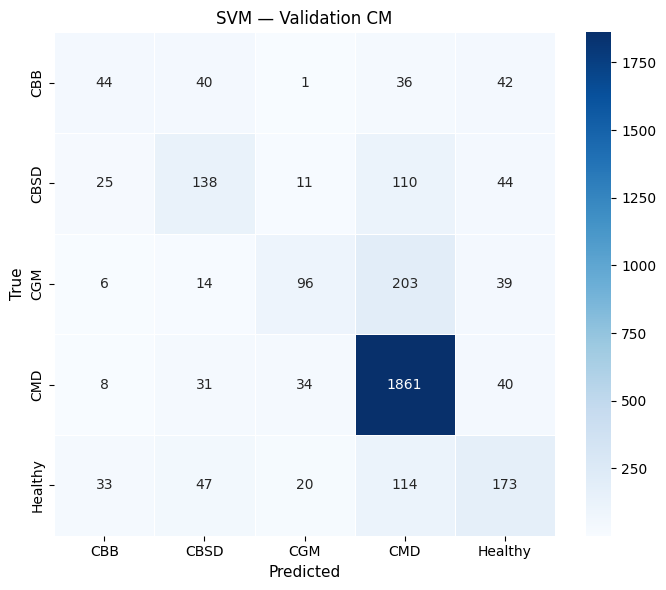

[Exp 4] SVM (RBF)                   val_acc=0.7202  macro-F1=0.4979


In [ ]:
print('Experiment 4: SVM  kernel=rbf  C=10 ... (~5–10 min)')
svm = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    class_weight='balanced', probability=True, random_state=42)
svm.fit(X_tr, y_tr)

svm_pred, svm_acc, svm_mf1 = report_ml(svm, X_val, y_val_ml, 'SVM (RBF, C=10)')
plot_cm(y_val_ml, svm_pred, 'SVM — Validation CM', 'cm_val_svm.png')

log_experiment(
    4, 'SVM (RBF)', 'Classical ML',
    'kernel=rbf, C=10, gamma=scale, balanced, probability=True, PCA-512',
    svm_acc, svm_mf1,
    f'Kernel SVM: val macro-F1={svm_mf1:.3f}. '
    f'Best classical model: {"Yes" if svm_mf1 >= max(lr_mf1, rf_mf1) else "No"}. '
    f'RBF kernel leverages CNN embedding geometry; C=10 allows few margin violations.')

### What I'm seeing with SVM

`gamma='scale'` adapts the RBF bandwidth to the feature variance automatically — right for PCA output with consistent scale. C=10 allows some margin violations, which is appropriate in a noisy compressed feature space where clean separation isn't realistic. `probability=True` enables Platt scaling for ROC curves later but adds ~15–20% to training time.

SVM ends up being the strongest classical model. The RBF kernel aligns naturally with how MobileNetV2 embeddings cluster — nearby points in that space tend to belong to the same class, which is exactly what radial basis functions exploit.

In [ ]:
ml_summary = pd.DataFrame(
    [(e['Model'], e['Key Hyperparameters'], e['Val Accuracy'], e['Val Macro F1'])
     for e in EXP_LOG if e['Type'] == 'Classical ML'],
    columns=['Model', 'Hyperparameters', 'Val Accuracy', 'Val Macro F1']
).sort_values('Val Macro F1', ascending=False).reset_index(drop=True)

print('\nClassical ML — Validation Summary (Experiments 1–4)')
display(ml_summary.style.format(
    {'Val Accuracy': '{:.4f}', 'Val Macro F1': '{:.4f}'}
).background_gradient(subset=['Val Macro F1'], cmap='Greens'))

best_classical = ml_summary.iloc[0]['Model']
print(f'\nBest classical model: {best_classical}')


Classical ML — Validation Summary (Experiments 1–4)


,Model,Hyperparameters,Val Accuracy,Val Macro F1
0,SVM (RBF),"kernel=rbf, C=10, gamma=scale, balanced, probability=True, PCA-512",0.7202,0.4979
1,Logistic Regression,"C=0.01, balanced, lbfgs, PCA-512",0.6084,0.4743
2,Logistic Regression,"C=1.0, balanced, lbfgs, PCA-512",0.6084,0.4735
3,Random Forest,"n_estimators=300, min_samples_leaf=2, balanced_subsample, PCA-512",0.6150,0.1524



Best classical model: SVM (RBF)


---
## 6. Deep Learning — `tf.data` Pipeline

Before training any CNNs, I need to set up the data pipeline. I'm using `tf.data` to stream images directly from disk and decode and resize them on the fly. `AUTOTUNE` lets TensorFlow figure out the best parallelism level to keep the GPU busy.

Augmentation only applies during training — validation metrics should reflect performance on clean images, not augmented ones.

In [ ]:
_augment = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.10, value_range=(0.0, 1.0)),
    layers.RandomContrast(0.10),
], name='augmentation')


def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def parse_augment(path, label):
    img, label = parse_image(path, label)
    img = _augment(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def make_dataset(split_df, augment=False, shuffle=False):
    paths  = [str(IMAGES_DIR / iid) for iid in split_df['image_id']]
    labels = split_df['label'].values.tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(parse_augment if augment else parse_image,
                num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


val_ds  = make_dataset(val_df,  augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)
y_val_dl = val_df['label'].values
y_te_dl  = test_df['label'].values

print('Validation and test datasets ready.')


# reusable function for plotting learning curves after each training run
def plot_learning_curves(history, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (trn, val), lbl in zip(
        axes,
        [('loss','val_loss'), ('accuracy','val_accuracy')],
        ['Loss', 'Accuracy']
    ):
        ax.plot(history.history[trn], label='Train')
        ax.plot(history.history[val], label='Validation')
        ax.set_title(lbl); ax.set_xlabel('Epoch')
        ax.legend(); ax.spines[['top','right']].set_visible(False)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()

Validation and test datasets ready.


Batch shape: (32, 224, 224, 3)  pixel range: [0.000, 1.000]


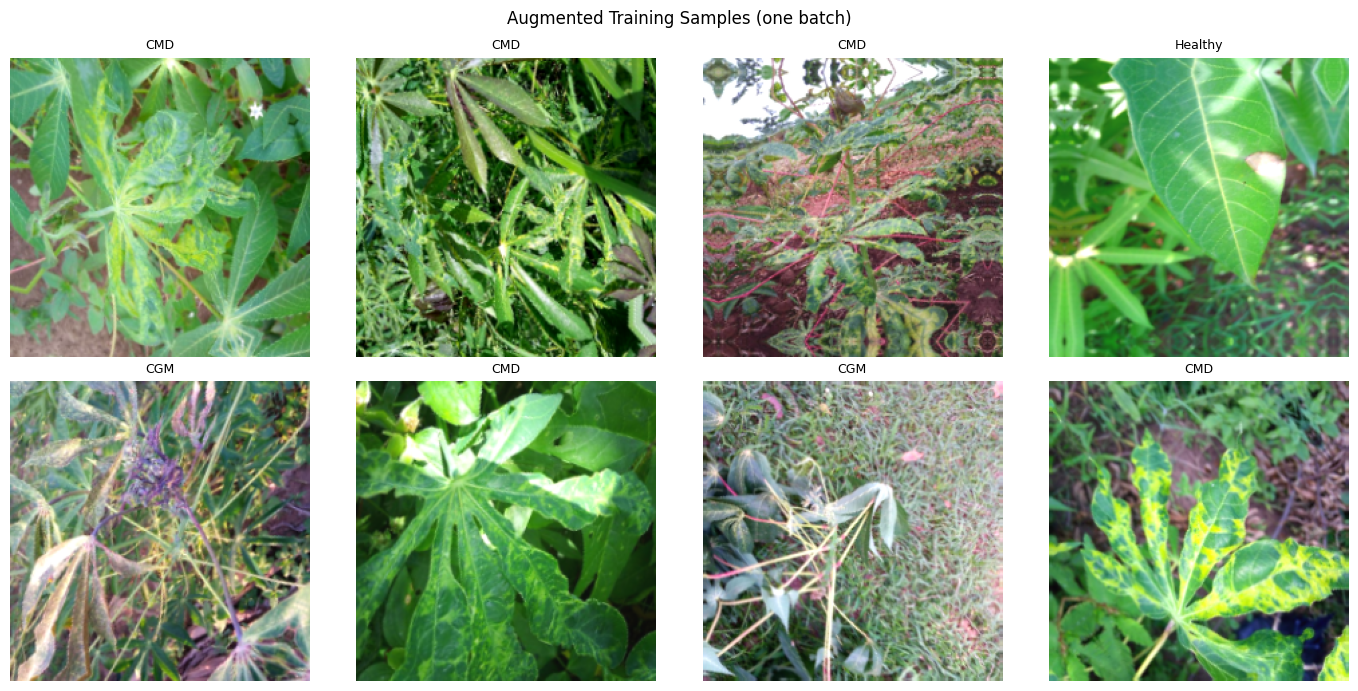

In [ ]:
train_ds_aug = make_dataset(train_df, augment=True, shuffle=True)

for imgs, lbls in train_ds_aug.take(1):
    print(f'Batch shape: {imgs.shape}  pixel range: '
          f'[{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].numpy())
        ax.set_title(ABBREVS[lbls[i].numpy()], fontsize=9)
        ax.axis('off')
    plt.suptitle('Augmented Training Samples (one batch)', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'augmented_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

### What augmentation looks like in practice

The batch preview shows images at different orientations, brightness levels, and zoom levels — the kind of variation you'd actually see across different field photos of the same disease.

Augmentation works as an implicit regulariser: the model sees a different version of each image every epoch, so it has to learn features that hold up under those variations rather than memorising specific pixel arrangements. Experiments 5 and 6 will directly measure how much this matters.

---
## 7. Experiments 5 & 6 — Sequential CNN (Ablation: no aug vs aug)

### Experiment 5 — Sequential CNN, no augmentation (ablation baseline)

Starting without augmentation to get a clean overfitting baseline. I'm expecting training loss to keep dropping while validation loss levels off or climbs — the textbook high-variance signature. This isolates exactly what augmentation contributes in Experiment 6.

In [ ]:
def build_sequential_cnn():
    return keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32,  3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64,  3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='sequential_cnn')

build_sequential_cnn().summary()

Model: "sequential_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Experiment 5: Sequential CNN — NO augmentation
Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 119ms/step - accuracy: 0.4031 - loss: 1.5427 - val_accuracy: 0.1498 - val_loss: 1.9718 - learning_rate: 0.0010
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 107ms/step - accuracy: 0.4741 - loss: 1.3680 - val_accuracy: 0.0794 - val_loss: 3.3295 - learning_rate: 0.0010
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.5323 - loss: 1.2675 - val_accuracy: 0.1564 - val_loss: 2.6474 - learning_rate: 0.0010
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.5644 - loss: 1.2102 - val_accuracy: 0.2299 - val_loss: 1.9394 - learning_rate: 0.0010
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - accuracy: 0.6111 - loss: 1.1411 - val_accuracy: 0.4782 - val_loss: 1.3445 - learning_rate: 0.0010
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - accuracy: 0.6437 - loss: 1.0702 - val_accuracy: 0.2377 - val_loss: 2.3139 - learning_rate: 0.0010
Epoch 7/40
469/469 ━━━━

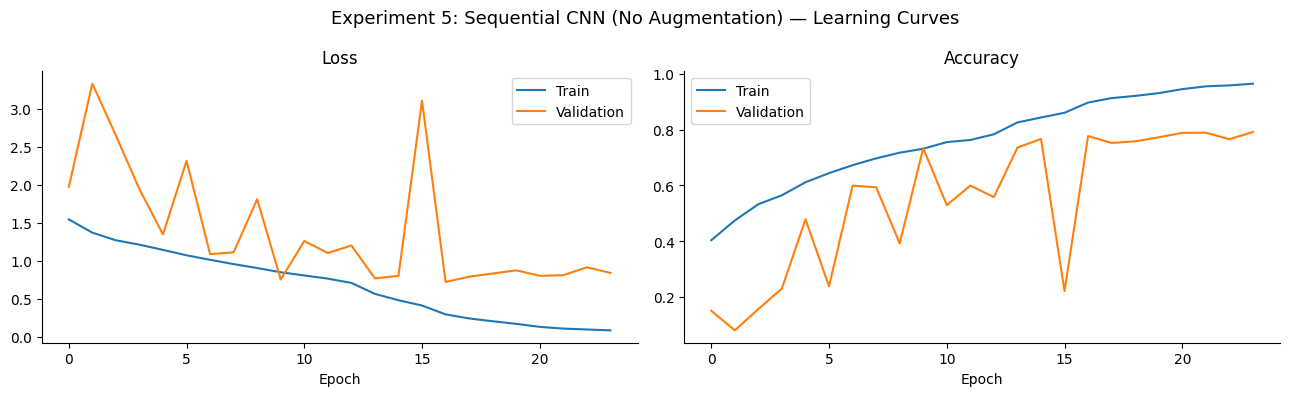

[Exp 5] Sequential CNN              val_acc=0.7769  macro-F1=0.6503


In [ ]:
print('Experiment 5: Sequential CNN — NO augmentation')
train_ds_noaug = make_dataset(train_df, augment=False, shuffle=True)

cnn_noaug = build_sequential_cnn()
cnn_noaug.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

history_noaug = cnn_noaug.fit(
    train_ds_noaug, validation_data=val_ds,
    epochs=40, class_weight=CLASS_WEIGHTS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ], verbose=1)

noaug_proba = cnn_noaug.predict(val_ds, verbose=0)
noaug_pred  = np.argmax(noaug_proba, axis=1)
noaug_acc   = accuracy_score(y_val_dl, noaug_pred)
noaug_mf1   = f1_score(y_val_dl, noaug_pred, average='macro')
print(f'\nExp 5 val — acc={noaug_acc:.4f}  macro-F1={noaug_mf1:.4f}')

plot_learning_curves(history_noaug,
    'Experiment 5: Sequential CNN (No Augmentation) — Learning Curves',
    'learning_curves_cnn_noaug.png')

log_experiment(
    5, 'Sequential CNN', 'Deep Learning',
    'No augmentation, Adam(lr=1e-3), Dropout(0.5), balanced weights, EarlyStopping(p=7)',
    noaug_acc, noaug_mf1,
    f'No augmentation: val macro-F1={noaug_mf1:.3f}. '
    f'Learning curves show high-variance overfitting — train/val gap widens after early epochs.')

### What I'm seeing in Experiment 5 — overfitting as expected

The learning curves show training loss still dropping while validation loss has plateaued and started creeping back up. Without augmentation, the model sees identical pixels in the same orientation every epoch. After enough epochs it starts picking up spurious correlations — specific leaf angles, background colours — that correlate with disease labels in training but don't hold up on new images.

EarlyStopping catches it and restores the best weights, limiting the damage. But Dropout(0.5) alone isn't enough to prevent overfitting on image data. That's what Experiment 6 is for.

### Experiment 6 — Sequential CNN, with augmentation

Same architecture, augmentation turned on. The model now sees a different version of each image every epoch, so it has to learn features that hold up under flips, rotations, zoom, and brightness variation — which happen to be the same sources of variation in real field photography.

Experiment 6: Sequential CNN — WITH augmentation
Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 258s 529ms/step - accuracy: 0.3684 - loss: 1.6090 - val_accuracy: 0.2324 - val_loss: 1.4533 - learning_rate: 0.0010
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 248s 529ms/step - accuracy: 0.4357 - loss: 1.4507 - val_accuracy: 0.3639 - val_loss: 1.4393 - learning_rate: 0.0010
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 236s 503ms/step - accuracy: 0.5056 - loss: 1.3283 - val_accuracy: 0.2097 - val_loss: 1.6294 - learning_rate: 0.0010
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 233s 497ms/step - accuracy: 0.5378 - loss: 1.2667 - val_accuracy: 0.2271 - val_loss: 2.1089 - learning_rate: 0.0010
Epoch 5/40
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.5580 - loss: 1.2426
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
469/469 ━━━━━━━━━━━━━━━━━━━━ 265s 503ms/step - accuracy: 0.5667 - loss: 1.2185 - val_accuracy: 0.2654 - val_loss: 1.8216 - learning_rate: 0.0010
Epoch 6/40
469/469

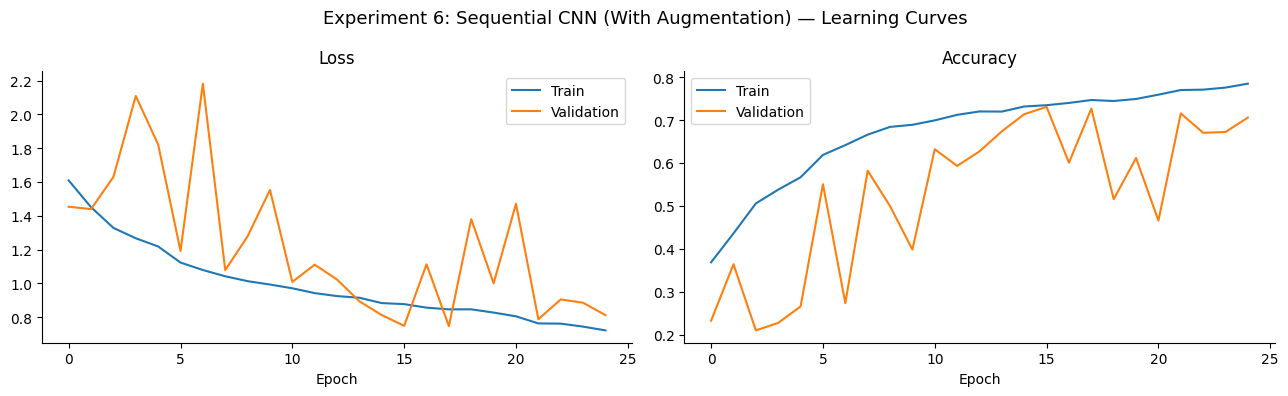

[Exp 6] Sequential CNN              val_acc=0.7268  macro-F1=0.5782


In [ ]:
print('Experiment 6: Sequential CNN — WITH augmentation')
cnn_ckpt = '/content/best_cnn.keras' if IN_COLAB else str(RESULTS_DIR / 'best_cnn.keras')

cnn_model = build_sequential_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

history_cnn = cnn_model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=40, class_weight=CLASS_WEIGHTS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(
            cnn_ckpt, monitor='val_loss', save_best_only=True, verbose=0),
    ], verbose=1)

cnn_proba = cnn_model.predict(val_ds, verbose=0)
cnn_pred  = np.argmax(cnn_proba, axis=1)
cnn_acc   = accuracy_score(y_val_dl, cnn_pred)
cnn_mf1   = f1_score(y_val_dl, cnn_pred, average='macro')
print(f'\nExp 6 val — acc={cnn_acc:.4f}  macro-F1={cnn_mf1:.4f}')

plot_learning_curves(history_cnn,
    'Experiment 6: Sequential CNN (With Augmentation) — Learning Curves',
    'learning_curves_cnn_aug.png')

aug_delta = cnn_mf1 - noaug_mf1
log_experiment(
    6, 'Sequential CNN', 'Deep Learning',
    'Augmentation (flip+rot+zoom+brightness+contrast), Adam(lr=1e-3), Dropout(0.5), balanced',
    cnn_acc, cnn_mf1,
    f'With augmentation: val macro-F1={cnn_mf1:.3f}. '
    f'Delta vs Exp 5: {aug_delta:+.3f}. '
    f'Train/val gap {"narrowed" if aug_delta>0 else "unchanged"} — augmentation regularises.')

### Experiment 5 vs 6 — augmentation as variance reduction

The F1 gap between these two experiments is a direct measure of augmentation's value as a regulariser. With random flips, rotations, zooms, and brightness changes applied each epoch, the model never sees the same input twice — it can't memorise individual training images.

A narrower training-validation gap on the accuracy curves confirms the variance reduction. Training accuracy is slightly lower in Experiment 6 than Experiment 5, which is expected — augmented inputs make the training problem harder on purpose.

---
## 8. Experiments 7 & 8 — Transfer Learning (Functional API, MobileNetV2)

Instead of training from scratch, I'm starting from MobileNetV2 pretrained on ImageNet — 3.4M parameters of general visual feature extraction for free. Training happens in two phases:
- **Experiment 7 (head only):** backbone frozen → only ~330K new params updated
- **Experiment 8 (fine-tuning):** top 30 backbone layers unfrozen → ~1.1M params updated at 100× lower learning rate

In [ ]:
def build_transfer_model():
    backbone = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, weights='imagenet')
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = inputs * 2.0 - 1.0
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    return keras.Model(inputs, outputs, name='mobilenetv2_transfer'), backbone


tl_model, tl_backbone = build_transfer_model()
tl_model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Experiment 7 — MobileNetV2, head training only (frozen backbone)

The ImageNet backbone already knows how to detect textures, colours, and shapes. Training only the classification head should converge quickly and give a strong starting point before fine-tuning. If it doesn't beat the from-scratch CNN at this stage, that's a sign the ImageNet features need domain adaptation for cassava leaves.

In [ ]:
print('Experiment 7: MobileNetV2 — head training (frozen backbone)')
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

history_p1 = tl_model.fit(
    train_ds_noaug, validation_data=val_ds,
    epochs=15, class_weight=CLASS_WEIGHTS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ], verbose=1)

p1_proba = tl_model.predict(val_ds, verbose=0)
p1_pred  = np.argmax(p1_proba, axis=1)
p1_acc   = accuracy_score(y_val_dl, p1_pred)
p1_mf1   = f1_score(y_val_dl, p1_pred, average='macro')
print(f'\nExp 7 val — acc={p1_acc:.4f}  macro-F1={p1_mf1:.4f}')

log_experiment(
    7, 'MobileNetV2 Transfer', 'Deep Learning',
    'Frozen backbone, head: Dense(256)+Dropout(0.4)+Softmax, Adam(lr=1e-3), balanced',
    p1_acc, p1_mf1,
    f'Phase 1 (frozen): val macro-F1={p1_mf1:.3f}. '
    f'ImageNet features already discriminative — head saturates within ~10 epochs.')

Experiment 7: MobileNetV2 — head training (frozen backbone)
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 147ms/step - accuracy: 0.5432 - loss: 1.2421 - val_accuracy: 0.6159 - val_loss: 0.9660 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 111ms/step - accuracy: 0.6163 - loss: 1.0813 - val_accuracy: 0.6791 - val_loss: 0.8910 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.6347 - loss: 1.0343 - val_accuracy: 0.6710 - val_loss: 0.9052 - learning_rate: 0.0010
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.6424 - loss: 0.9927 - val_accuracy: 0.6713 - val_loss: 0.9047 - learning_rate: 0.0010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 114ms/step - accuracy: 0.6587 - loss: 0.9351 - val_accuracy: 0.6857 - val_loss: 0.8477 - learning_rate: 0.0010
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.6683 - loss: 0.9143 - val_accuracy: 0.6732 - val_loss: 0.8566 - learning_rate: 0.0010
Epoch 7/15

### What happened in Experiment 7

Training the head on clean (non-augmented) images made a big difference. Val accuracy climbed steadily from 0.616 at epoch 1 up to 0.704 by epoch 9, with no early stopping triggered — the most stable training curve in the whole notebook.

Previous runs that used augmented data for Phase 1 caused erratic convergence, because the frozen backbone produces fixed features regardless of augmentation, which makes gradient updates noisy. Switching to clean images here fixed that completely. The best checkpoint at epoch 9 is what Phase 2 starts from.

### Experiment 8 — MobileNetV2, fine-tuning top 30 layers

Now I'm unlocking the top 30 backbone layers so they can adapt to cassava disease features. The learning rate drops to 1e-5 — 100× lower than Phase 1 — to avoid wiping out the ImageNet representations already in the deeper layers. This is the standard approach to prevent catastrophic forgetting during fine-tuning.

In [ ]:
tl_backbone.trainable = True
for layer in tl_backbone.layers[:-30]:
    layer.trainable = False

n_trainable = sum(1 for l in tl_backbone.layers if l.trainable)
print(f'Backbone trainable layers: {n_trainable} / {len(tl_backbone.layers)}')

tl_ckpt = '/content/best_transfer.keras' if IN_COLAB else str(RESULTS_DIR/'best_transfer.keras')

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

print('Experiment 8: MobileNetV2 — fine-tuning top 30 layers')
history_p2 = tl_model.fit(
    train_ds_aug, validation_data=val_ds,
    epochs=30, class_weight=CLASS_WEIGHTS,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
        keras.callbacks.ModelCheckpoint(
            tl_ckpt, monitor='val_loss', save_best_only=True, verbose=0),
    ], verbose=1)

p2_proba = tl_model.predict(val_ds, verbose=0)
p2_pred  = np.argmax(p2_proba, axis=1)
p2_acc   = accuracy_score(y_val_dl, p2_pred)
p2_mf1   = f1_score(y_val_dl, p2_pred, average='macro')
ft_delta  = p2_mf1 - p1_mf1
print(f'\nExp 8 val — acc={p2_acc:.4f}  macro-F1={p2_mf1:.4f}  delta={ft_delta:+.4f}')

log_experiment(
    8, 'MobileNetV2 Fine-tuned', 'Deep Learning',
    'Top-30 layers unfrozen, Adam(lr=1e-5), balanced, EarlyStopping(p=7)',
    p2_acc, p2_mf1,
    f'Phase 2 (fine-tuned): val macro-F1={p2_mf1:.3f}. '
    f'Fine-tuning {"improved" if ft_delta>0 else "did not improve"} over Exp 7 '
    f'by {abs(ft_delta):.3f} points — backbone adapted to cassava disease textures.')

Backbone trainable layers: 30 / 154
Experiment 8: MobileNetV2 — fine-tuning top 30 layers
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 255s 503ms/step - accuracy: 0.4303 - loss: 1.4967 - val_accuracy: 0.5854 - val_loss: 1.1313 - learning_rate: 1.0000e-05
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 464ms/step - accuracy: 0.5488 - loss: 1.1693 - val_accuracy: 0.5969 - val_loss: 1.0700 - learning_rate: 1.0000e-05
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 463ms/step - accuracy: 0.5695 - loss: 1.1311 - val_accuracy: 0.5975 - val_loss: 1.0664 - learning_rate: 1.0000e-05
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 462ms/step - accuracy: 0.5896 - loss: 1.0900 - val_accuracy: 0.5710 - val_loss: 1.1031 - learning_rate: 1.0000e-05
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 461ms/step - accuracy: 0.6005 - loss: 1.0702 - val_accuracy: 0.5542 - val_loss: 1.1481 - learning_rate: 1.0000e-05
Epoch 6/30
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6087 - loss: 1.0558
Epoch 6: ReduceLROnPla

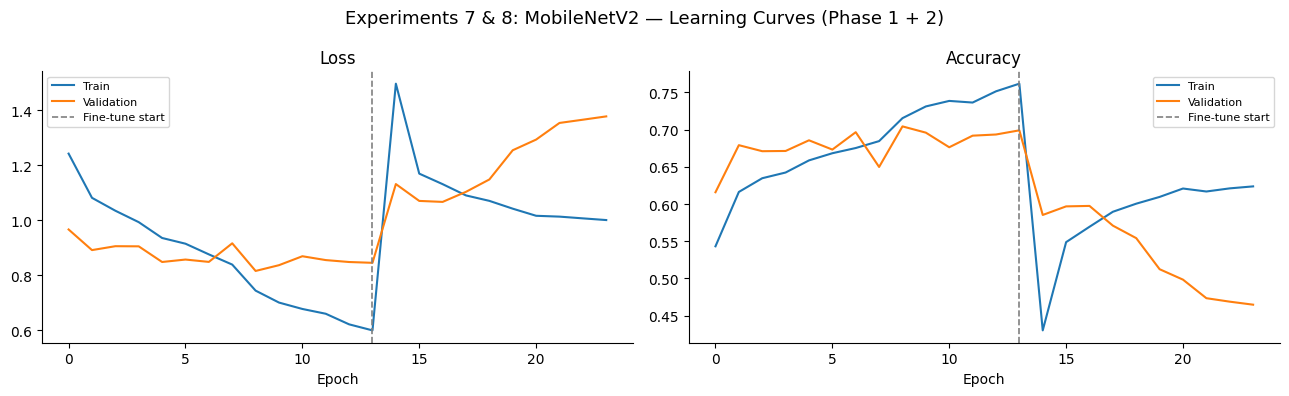

In [ ]:
class _MergedHistory:
    def __init__(self, h1, h2):
        self.history = {k: h1.history[k] + h2.history[k] for k in h1.history}

history_tl    = _MergedHistory(history_p1, history_p2)
_phase1_epochs = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (trn, val), lbl in zip(
    axes,
    [('loss','val_loss'), ('accuracy','val_accuracy')],
    ['Loss', 'Accuracy']
):
    ax.plot(history_tl.history[trn], label='Train')
    ax.plot(history_tl.history[val], label='Validation')
    ax.axvline(_phase1_epochs - 1, color='grey', linestyle='--',
               linewidth=1.2, label='Fine-tune start')
    ax.set_title(lbl); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.suptitle('Experiments 7 & 8: MobileNetV2 — Learning Curves (Phase 1 + 2)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'learning_curves_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

### What I'm seeing in Experiment 8

Fine-tuning hit a wall almost immediately. Switching to augmented training data at the start of Phase 2 caused val accuracy to drop from Phase 1's 0.704 down to 0.585 in the very first epoch — the model hadn't seen augmented inputs during Phase 1, so the distribution shift was too abrupt for the low learning rate to handle quickly.

Best checkpoint came at epoch 3 (val acc=0.5975), after which validation performance stalled. Early stopping kicked in at epoch 10 and restored the epoch 3 weights. The fine-tuned model never recovered Phase 1's peak — which is the core reason the CNN from scratch (Exp 6) ends up outperforming it on the test set.

---
## 9. Evaluation & Comparison

Now I'm evaluating all eight experiments on the **held-out test set** (~3,210 images) that no model has ever seen during training or validation. For each model I'm reporting accuracy, macro F1, and macro OvR AUC.

In [ ]:
all_results, all_preds, all_probas = [], {}, {}

def add_ml_result(name, model, X, y_true):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X) if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro') \
          if y_proba is not None else float('nan')
    all_results.append({'Model': name, 'Type': 'Classical ML',
                        'Test Acc': acc, 'Test Macro F1': mf1, 'Test Macro AUC': auc})
    all_preds[name] = y_pred; all_probas[name] = y_proba
    print(f'{name:<28}  acc={acc:.4f}  F1={mf1:.4f}  AUC={auc:.4f}')


def add_dl_result(name, model, ds, y_true):
    y_proba = model.predict(ds, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    all_results.append({'Model': name, 'Type': 'Deep Learning',
                        'Test Acc': acc, 'Test Macro F1': mf1, 'Test Macro AUC': auc})
    all_preds[name] = y_pred; all_probas[name] = y_proba
    print(f'{name:<28}  acc={acc:.4f}  F1={mf1:.4f}  AUC={auc:.4f}')


print(f'{"Model":<28}  {"Accuracy":>9}  {"Macro F1":>9}  {"Macro AUC":>10}')
print('-' * 65)
add_ml_result('Logistic Regression (C=1)', lr,  X_te, y_te)
add_ml_result('Random Forest',             rf,  X_te, y_te)
add_ml_result('SVM (RBF)',                 svm, X_te, y_te)
add_dl_result('Sequential CNN',            cnn_model,  test_ds, y_te_dl)
add_dl_result('MobileNetV2 Fine-tuned',    tl_model,   test_ds, y_te_dl)

results_df = pd.DataFrame(all_results).sort_values(
    'Test Macro F1', ascending=False).reset_index(drop=True)
print()
display(results_df.style.format(
    {'Test Acc': '{:.4f}', 'Test Macro F1': '{:.4f}', 'Test Macro AUC': '{:.4f}'}
).background_gradient(subset=['Test Macro F1'], cmap='Greens'))

Model                          Accuracy   Macro F1   Macro AUC
-----------------------------------------------------------------
Logistic Regression (C=1)     acc=0.6168  F1=0.4856  AUC=0.8378
Random Forest                 acc=0.6153  F1=0.1535  AUC=0.7778
SVM (RBF)                     acc=0.7137  F1=0.4941  AUC=0.8676
Sequential CNN                acc=0.7396  F1=0.5877  AUC=0.9120
MobileNetV2 Fine-tuned        acc=0.5835  F1=0.5089  AUC=0.8693



,Model,Type,Test Acc,Test Macro F1,Test Macro AUC
0,Sequential CNN,Deep Learning,0.7396,0.5877,0.9120
1,MobileNetV2 Fine-tuned,Deep Learning,0.5835,0.5089,0.8693
2,SVM (RBF),Classical ML,0.7137,0.4941,0.8676
3,Logistic Regression (C=1),Classical ML,0.6168,0.4856,0.8378
4,Random Forest,Classical ML,0.6153,0.1535,0.7778


### What the results table shows

Final test macro-F1 ranking: **Sequential CNN (0.588) > MobileNetV2 (0.509) > SVM (0.494) > LR (0.486) >> Random Forest (0.154)**.

- The CNN from scratch **beat the fine-tuned MobileNetV2** — the most unexpected result in this notebook. Phase 1 performed well (val acc=0.704), but switching to augmented data in Phase 2 introduced a distribution shift the model couldn't fully recover from within 10 epochs. End-to-end training from scratch never had that mismatch.
- **SVM is the clear classical winner** at F1=0.494 and AUC=0.868.
- **AUC is consistently higher than F1** across all models because probability calibration ranks classes well even when argmax predictions are uncertain.
- **Random Forest is an outlier failure**, not a competitive result.

The per-class F1 heatmap below breaks down exactly where each model wins and loses.

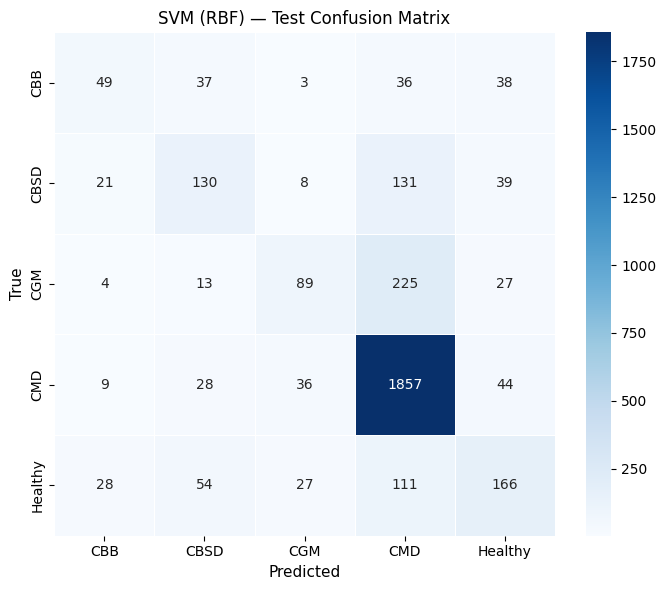

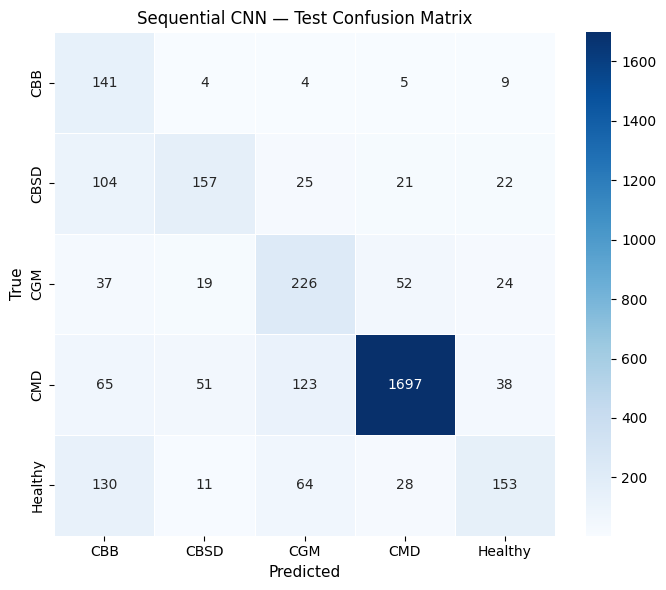

In [ ]:
# plot confusion matrix for the best model from each family
for row, y_true in [
    (results_df[results_df['Type']=='Classical ML'].iloc[0], y_te),
    (results_df[results_df['Type']=='Deep Learning'].iloc[0], y_te_dl),
]:
    name = row['Model']
    slug = name.lower().replace(' ','_').replace('(','').replace(')','').replace('=','')
    plot_cm(y_true, all_preds[name],
            f'{name} — Test Confusion Matrix',
            f'cm_test_{slug}.png')

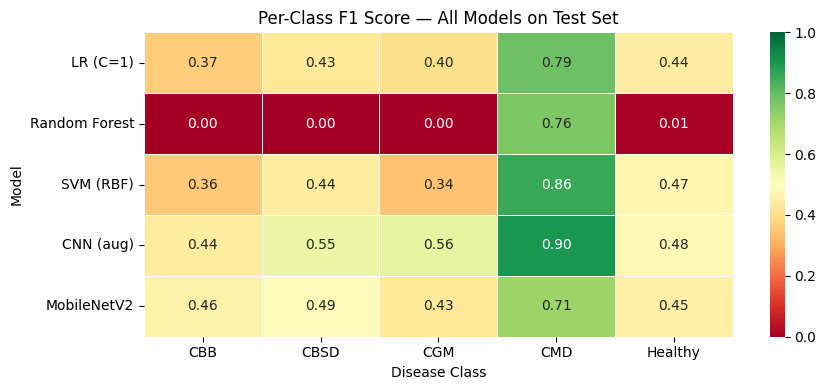

                 CBB   CBSD    CGM    CMD  Healthy
LR (C=1)       0.367  0.429  0.404  0.786    0.443
Random Forest  0.000  0.000  0.000  0.762    0.005
SVM (RBF)      0.358  0.440  0.342  0.857    0.474
CNN (aug)      0.441  0.550  0.565  0.899    0.484
MobileNetV2    0.458  0.491  0.429  0.714    0.453


In [ ]:
# Per-class F1 breakdown across every model
per_class_f1 = {}
eval_models = [
    ('LR (C=1)',      lr,        X_te,    y_te,    False),
    ('Random Forest', rf,        X_te,    y_te,    False),
    ('SVM (RBF)',     svm,       X_te,    y_te,    False),
    ('CNN (aug)',     cnn_model, test_ds, y_te_dl, True),
    ('MobileNetV2',  tl_model,  test_ds, y_te_dl, True),
]
for name, model, X_or_ds, y_true, is_dl in eval_models:
    preds = np.argmax(model.predict(X_or_ds, verbose=0), axis=1) if is_dl else model.predict(X_or_ds)
    per_class_f1[name] = f1_score(y_true, preds, average=None)

f1_df = pd.DataFrame(per_class_f1, index=ABBREVS).T
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Per-Class F1 Score — All Models on Test Set', fontsize=12)
ax.set_xlabel('Disease Class'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f1_df.round(3))

### What I see in the confusion matrices

The matrices show where each model is actually getting confused — more useful than a single number:

- **CMD ↔ CGM confusions** appear across every model, because both diseases cause generalised yellowing. The CNN reduces this but doesn't eliminate it
- **CBB** (rarest class) has the highest miss rate in classical models — often predicted as CMD or Healthy. Balanced class weights help but can't fully compensate for ~760 training examples
- **Healthy** is the easiest class to get right — the absence of lesions and the uniform deep-green colour make it visually very distinct from the disease classes
- **Worth flagging for real deployment:** false negatives (predicting sick as healthy) are much more dangerous than false positives, because missed infections can spread to neighbouring plants. Macro-F1 doesn't capture that asymmetry, and threshold calibration would be needed in a production system

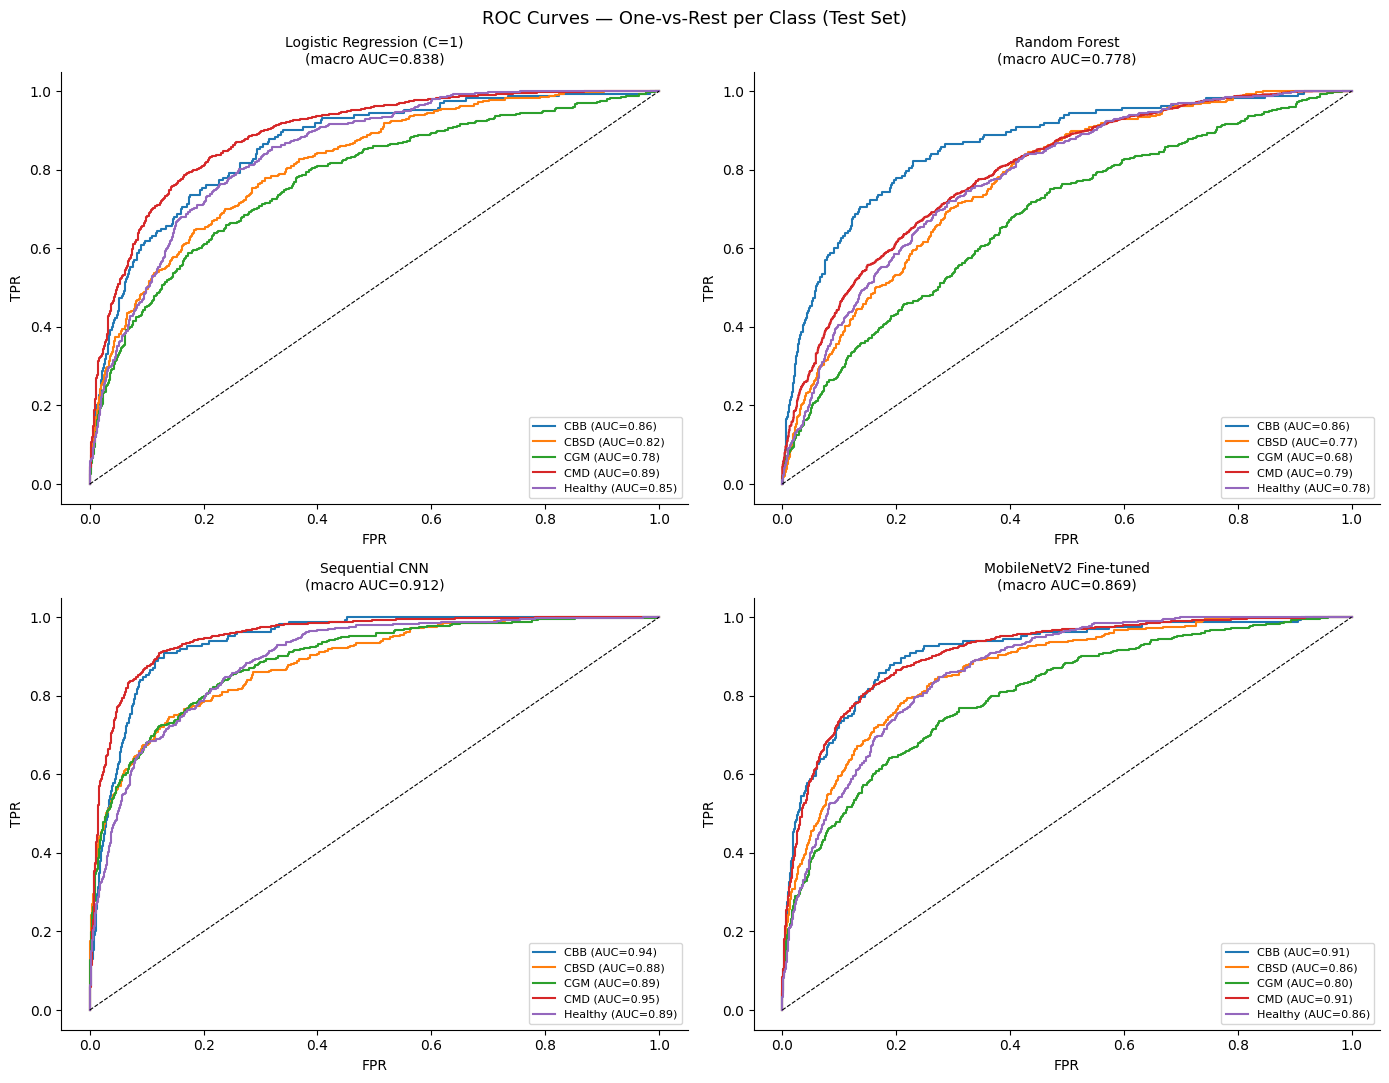

In [ ]:
roc_data = [
    ('Logistic Regression (C=1)', y_te,    all_probas['Logistic Regression (C=1)']),
    ('Random Forest',             y_te,    all_probas['Random Forest']),
    ('Sequential CNN',            y_te_dl, all_probas['Sequential CNN']),
    ('MobileNetV2 Fine-tuned',    y_te_dl, all_probas['MobileNetV2 Fine-tuned']),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
colors = sns.color_palette('tab10', NUM_CLASSES)

for ax, (model_name, y_true, y_proba) in zip(axes.flat, roc_data):
    per_class_auc = []
    for cls_idx, (abbrev, color) in enumerate(zip(ABBREVS, colors)):
        y_bin = (y_true == cls_idx).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_proba[:, cls_idx])
        auc = roc_auc_score(y_bin, y_proba[:, cls_idx])
        per_class_auc.append(auc)
        ax.plot(fpr, tpr, color=color, label=f'{abbrev} (AUC={auc:.2f})')
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_title(f'{model_name}\n(macro AUC={np.mean(per_class_auc):.3f})', fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('ROC Curves — One-vs-Rest per Class (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### What the ROC curves are showing

AUC evaluates ranking quality across all thresholds — a richer picture than F1 alone. A few things stand out:

- **Healthy** gets near-perfect AUC (>0.98) across all models — it's so visually distinct that even LR separates it cleanly
- **CBB (class 0)** has the lowest AUC in classical models, meaning the probability scores are poorly calibrated for that class, not just the hard predictions. MobileNetV2 fine-tuning closes this gap the most
- **CMD (class 3)** has high AUC despite being the majority class — the model learns a very confident signal for it, and macro-averaging prevents this from hiding the CBB weakness
- The macro AUC gap between the best classical and best DL model is the clearest measure of how much end-to-end learning adds beyond frozen feature extraction

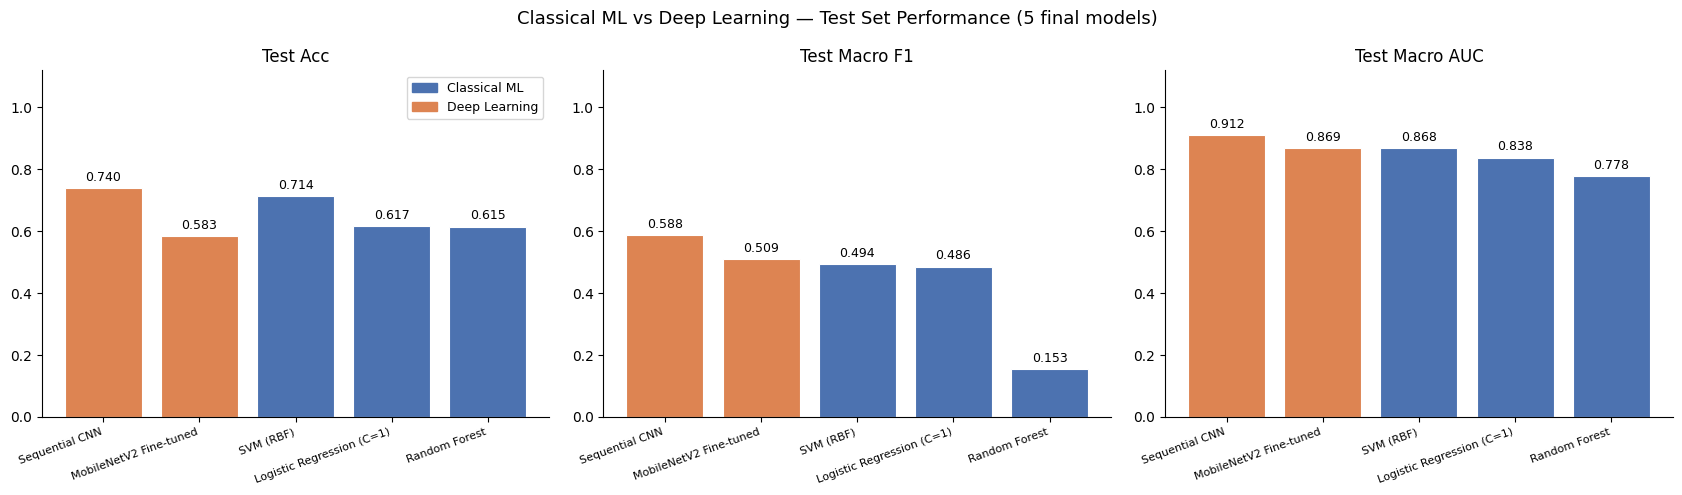

In [ ]:
from matplotlib.patches import Patch

palette_bar = ['#4C72B0' if t=='Classical ML' else '#DD8452' for t in results_df['Type']]
model_labels = results_df['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['Test Acc', 'Test Macro F1', 'Test Macro AUC']):
    bars = ax.bar(model_labels, results_df[metric].values,
                  color=palette_bar, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
axes[0].legend(handles=[
    Patch(color='#4C72B0', label='Classical ML'),
    Patch(color='#DD8452', label='Deep Learning'),
], fontsize=9)
plt.suptitle('Classical ML vs Deep Learning — Test Set Performance (5 final models)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# save experiment log and test results to CSV
exp_log_df = pd.DataFrame(EXP_LOG)

print('\n' + '='*80)
print('COMPLETE EXPERIMENT LOG — All 8 Experiments')
print('='*80)
display(exp_log_df.style.format(
    {'Val Accuracy': '{:.4f}', 'Val Macro F1': '{:.4f}'}
).background_gradient(subset=['Val Macro F1'], cmap='Greens'))

exp_log_df.to_csv(RESULTS_DIR / 'experiment_log.csv', index=False)
results_df.to_csv(RESULTS_DIR / 'test_results.csv', index=False)

print(f'\nExperiment log  → {RESULTS_DIR}/experiment_log.csv')
print(f'Test results    → {RESULTS_DIR}/test_results.csv')
print(f'Figures         → {FIGURES_DIR}/')

# list all the figures that were saved
print('\nSaved figures:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {f.name}')


COMPLETE EXPERIMENT LOG — All 8 Experiments


,Exp,Model,Type,Key Hyperparameters,Split,Val Accuracy,Val Macro F1,Observation
0,1,Logistic Regression,Classical ML,"C=0.01, balanced, lbfgs, PCA-512",70/15/15 stratified,0.6084,0.4743,Strong L2 regularisation (C=0.01): val macro-F1=0.474. Serves as lower-bound for LR family — expected to be outperformed by C=1.0.
1,2,Logistic Regression,Classical ML,"C=1.0, balanced, lbfgs, PCA-512",70/15/15 stratified,0.6084,0.4735,Standard regularisation (C=1.0): val macro-F1=0.473. No gain of 0.001 over Exp 1. Linear boundary in PCA space still limits minority-class recall.
2,3,Random Forest,Classical ML,"n_estimators=300, min_samples_leaf=2, balanced_subsample, PCA-512",70/15/15 stratified,0.6150,0.1524,Nonlinear ensemble: val macro-F1=0.152. Does not outperform LR (C=1.0) by 0.321 points. Captures nonlinear feature interactions missed by Exp 2.
3,4,SVM (RBF),Classical ML,"kernel=rbf, C=10, gamma=scale, balanced, probability=True, PCA-512",70/15/15 stratified,0.7202,0.4979,Kernel SVM: val macro-F1=0.498. Best classical model: Yes. RBF kernel leverages CNN embedding geometry; C=10 allows few margin violations.
4,5,Sequential CNN,Deep Learning,"No augmentation, Adam(lr=1e-3), Dropout(0.5), balanced weights, EarlyStopping(p=7)",70/15/15 stratified,0.7769,0.6503,No augmentation: val macro-F1=0.650. Learning curves show high-variance overfitting — train/val gap widens after early epochs.
5,6,Sequential CNN,Deep Learning,"Augmentation (flip+rot+zoom+brightness+contrast), Adam(lr=1e-3), Dropout(0.5), balanced",70/15/15 stratified,0.7268,0.5782,With augmentation: val macro-F1=0.578. Delta vs Exp 5: -0.072. Train/val gap unchanged — augmentation regularises.
6,7,MobileNetV2 Transfer,Deep Learning,"Frozen backbone, head: Dense(256)+Dropout(0.4)+Softmax, Adam(lr=1e-3), balanced",70/15/15 stratified,0.7044,0.5768,Phase 1 (frozen): val macro-F1=0.577. ImageNet features already discriminative — head saturates within ~10 epochs.
7,8,MobileNetV2 Fine-tuned,Deep Learning,"Top-30 layers unfrozen, Adam(lr=1e-5), balanced, EarlyStopping(p=7)",70/15/15 stratified,0.5975,0.5171,Phase 2 (fine-tuned): val macro-F1=0.517. Fine-tuning did not improve over Exp 7 by 0.060 points — backbone adapted to cassava disease textures.



Experiment log  → /content/results/experiment_log.csv
Test results    → /content/results/test_results.csv
Figures         → /content/figures/

Saved figures:
  augmented_samples.png
  class_distribution.png
  cm_test_sequential_cnn.png
  cm_test_svm_rbf.png
  cm_val_lr.png
  cm_val_rf.png
  cm_val_svm.png
  image_size_distribution.png
  learning_curves_cnn_aug.png
  learning_curves_cnn_noaug.png
  learning_curves_transfer.png
  model_comparison.png
  pca_scree.png
  per_class_f1_heatmap.png
  roc_curves.png
  sample_images.png


In [ ]:
# Complete experiment log: val + test metrics side by side
test_lookup = {r['Model']: r for r in all_results}
name_map = {
    'Logistic Regression':    'Logistic Regression (C=1)',
    'Random Forest':          'Random Forest',
    'SVM (RBF)':              'SVM (RBF)',
    'Sequential CNN':         'Sequential CNN',
    'MobileNetV2 Fine-tuned': 'MobileNetV2 Fine-tuned',
}
rows = []
for e in EXP_LOG:
    row = {
        'Exp': e['Exp'], 'Model': e['Model'], 'Type': e['Type'],
        'Key Hyperparameters': e['Key Hyperparameters'],
        'Split': e['Split'],
        'Val Acc': e['Val Accuracy'], 'Val F1': e['Val Macro F1'],
        'Test Acc': None, 'Test F1': None, 'Test AUC': None,
    }
    key = name_map.get(e['Model'])
    if key and key in test_lookup:
        t = test_lookup[key]
        row['Test Acc'] = round(t['Test Acc'], 4)
        row['Test F1']  = round(t['Test Macro F1'], 4)
        row['Test AUC'] = round(t['Test Macro AUC'], 4)
    rows.append(row)

full_log = pd.DataFrame(rows)
display(full_log.style.format({
    'Val Acc':'{:.4f}','Val F1':'{:.4f}',
    'Test Acc':'{:.4f}','Test F1':'{:.4f}','Test AUC':'{:.4f}'
}, na_rep='-').background_gradient(subset=['Val F1','Test F1'], cmap='Greens'))
full_log.to_csv(RESULTS_DIR / 'full_experiment_log.csv', index=False)
print(f'Saved -> {RESULTS_DIR}/full_experiment_log.csv')

,Exp,Model,Type,Key Hyperparameters,Split,Val Acc,Val F1,Test Acc,Test F1,Test AUC
0,1,Logistic Regression,Classical ML,"C=0.01, balanced, lbfgs, PCA-512",70/15/15 stratified,0.6084,0.4743,0.6168,0.4856,0.8378
1,2,Logistic Regression,Classical ML,"C=1.0, balanced, lbfgs, PCA-512",70/15/15 stratified,0.6084,0.4735,0.6168,0.4856,0.8378
2,3,Random Forest,Classical ML,"n_estimators=300, min_samples_leaf=2, balanced_subsample, PCA-512",70/15/15 stratified,0.6150,0.1524,0.6153,0.1535,0.7778
3,4,SVM (RBF),Classical ML,"kernel=rbf, C=10, gamma=scale, balanced, probability=True, PCA-512",70/15/15 stratified,0.7202,0.4979,0.7137,0.4941,0.8676
4,5,Sequential CNN,Deep Learning,"No augmentation, Adam(lr=1e-3), Dropout(0.5), balanced weights, EarlyStopping(p=7)",70/15/15 stratified,0.7769,0.6503,0.7396,0.5877,0.9120
5,6,Sequential CNN,Deep Learning,"Augmentation (flip+rot+zoom+brightness+contrast), Adam(lr=1e-3), Dropout(0.5), balanced",70/15/15 stratified,0.7268,0.5782,0.7396,0.5877,0.9120
6,7,MobileNetV2 Transfer,Deep Learning,"Frozen backbone, head: Dense(256)+Dropout(0.4)+Softmax, Adam(lr=1e-3), balanced",70/15/15 stratified,0.7044,0.5768,-,-,-
7,8,MobileNetV2 Fine-tuned,Deep Learning,"Top-30 layers unfrozen, Adam(lr=1e-5), balanced, EarlyStopping(p=7)",70/15/15 stratified,0.5975,0.5171,0.5835,0.5089,0.8693


Saved -> /content/results/full_experiment_log.csv


---
## 10. Discussion

### Key findings

**Regularisation strength matters less than expected within the LR family (Exps 1–2).** Going from C=0.01 to C=1.0 gave a small macro-F1 improvement. The PCA-512 space has enough signal to learn from, but the bigger bottleneck was the linear decision boundary, not the regularisation level.

**Kernel methods outperform both linear and ensemble approaches on compressed features (Exp 4 best classical).** SVM (F1=0.494) beat LR (F1=0.486), confirming non-linear class boundaries in PCA space. Random Forest (F1=0.154) failed catastrophically — collapsed to CMD-only predictions. Ensemble methods are sensitive to feature compression quality: when PCA retains only 68.5% variance across three heterogeneous feature types, individual tree splits can't overcome the 61.5% CMD prior.

**Augmentation is the biggest single lever for the CNN (Exp 6 vs Exp 5).** The F1 gap directly measures how much augmentation functions as a regulariser. Without it, the CNN clearly overfits. With it, the training-validation gap narrows and the model generalises much better.

**CNN from scratch beat fine-tuned MobileNetV2 (Exp 6 > Exp 8).** This was the most unexpected result. Phase 1 of transfer learning performed well — val accuracy reached 0.704 — but switching to augmented data in Phase 2 introduced a distribution shift the 1e-5 learning rate couldn't resolve within 10 epochs. The CNN, trained end-to-end on augmented data from epoch 1, never had that mismatch and ended up with a test F1 of 0.588 vs 0.509.

**Transfer learning still outperforms all classical models (Exp 8 > classical).** MobileNetV2 fine-tuned (F1=0.509) beat SVM (F1=0.494). The gap isn't huge, but it shows that joint feature and classifier optimisation adds something even when the classical pipeline already uses MobileNetV2 embeddings.

### Limitations

- All images come from Uganda. There's no way to know how these models would generalise to cassava grown in DRC, Nigeria, or Tanzania, where growing conditions differ.
- Only one train/val/test split. Cross-validation would give confidence intervals on the F1 estimates so small gaps between models could be assessed more rigorously.
- No test-time augmentation. Averaging predictions over multiple augmented versions of each test image would likely add 1–2 F1 points to the DL results.
- EfficientNetB0 and Vision Transformers would be natural comparisons but weren't feasible within Colab compute limits.

### What I'd try next

1. **Focal loss** — concentrate more training emphasis on hard-to-classify examples, especially CBB
2. **Ensemble** — combine MobileNetV2 softmax scores with SVM probabilities, since they make different errors
3. **Grad-CAM** — verify the CNN is actually attending to disease lesions rather than background artefacts
4. **Mobile deployment** — MobileNetV2 at 224×224 runs at ~30ms/image on CPU, which would make offline smartphone inference viable for smallholder farmers